In [16]:
"""
1D WILSON-COWAN SEIZURE MODEL - COMPREHENSIVE IMPLEMENTATION
Two numerical methods: RK45 and Finite Difference
Complete parameter sweeps for seizure studies
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import fftconvolve
from scipy.signal import find_peaks
import time
from matplotlib import cm
import matplotlib.gridspec as gridspec


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.signal import fftconvolve
from scipy.signal import find_peaks
import os
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print("1D WILSON-COWAN SEIZURE SIMULATION TOOLKIT")


1D WILSON-COWAN SEIZURE SIMULATION TOOLKIT


In [3]:
class WCParameters1D:
    """1D Wilson-Cowan parameter sets"""

    # Base parameters (1D version)
    BASE_PARAMS = {
        'tau_E': 10.0,      # Excitatory time constant (ms)
        'tau_I': 8.0,       # Inhibitory time constant (ms)
        'a_E': 1.3,         # Sigmoid slope for E
        'theta_E': 4.0,     # Sigmoid threshold for E
        'a_I': 2.0,         # Sigmoid slope for I
        'theta_I': 3.7,     # Sigmoid threshold for I
        'w_EE': 16.0,       # E->E connection strength
        'w_EI': 12.0,       # I->E connection strength
        'w_IE': 15.0,       # E->I connection strength
        'w_II': 3.0,        # I->I connection strength
        'r_E': 1.0,         # Refractory period for E
        'r_I': 1.0,         # Refractory period for I
        'P': 1.0,           # External input to E
        'Q': 1.0,           # External input to I
        'D_E': 0.01,        # Diffusion coefficient for E
        'D_I': 0.005,       # Diffusion coefficient for I
        'sigma_EE': 1.0,    # Spatial extent of E->E connections
        'sigma_EI': 2.0,    # Spatial extent of I->E connections
        'sigma_IE': 1.0,    # Spatial extent of E->I connections
        'sigma_II': 1.0,    # Spatial extent of I->I connections
        'L': 20.0,          # Domain length (mm)
        'N': 100,           # Number of spatial points
    }

    @staticmethod
    def get_healthy():
        """Healthy brain parameters"""
        params = WCParameters1D.BASE_PARAMS.copy()
        params.update({
            'w_EE': 16.0, 'w_EI': 12.0,  # Balanced E/I
            'D_E': 0.01, 'D_I': 0.005,   # Slow diffusion
            'case_name': 'Healthy Brain'
        })
        return params

    @staticmethod
    def get_seizure_prone(seizure_type='focal'):
        """Seizure parameters"""
        params = WCParameters1D.BASE_PARAMS.copy()

        if seizure_type == 'focal':
            # Focal seizure
            params.update({
                'w_EE': 24.0,   # Increased excitation
                'w_EI': 6.0,    # Reduced inhibition
                'D_E': 0.05,    # Moderate diffusion
                'case_name': 'Focal Seizure'
            })
        elif seizure_type == 'generalized':
            # Generalized seizure
            params.update({
                'w_EE': 28.0,   # Strong excitation
                'w_EI': 4.0,    # Weak inhibition
                'D_E': 0.1,     # Fast spread
                'case_name': 'Generalized Seizure'
            })
        elif seizure_type == 'absence':
            # Absence seizure
            params.update({
                'w_EE': 18.0,
                'w_EI': 9.0,
                'tau_E': 12.0,  # Slower E
                'tau_I': 6.0,   # Faster I
                'case_name': 'Absence Seizure'
            })

        return params

    @staticmethod
    def get_transition_scenarios():
        """Parameter scenarios for seizure transition studies"""
        scenarios = [
            {
                'name': 'Increasing Excitation',
                'param': 'w_EE',
                'values': [12.0, 16.0, 20.0, 24.0, 28.0],
                'healthy_range': (14.0, 18.0),
                'seizure_threshold': 22.0
            },
            {
                'name': 'Decreasing Inhibition',
                'param': 'w_EI',
                'values': [15.0, 12.0, 9.0, 6.0, 3.0],
                'healthy_range': (10.0, 14.0),
                'seizure_threshold': 7.0
            },
            {
                'name': 'Increasing Spread',
                'param': 'D_E',
                'values': [0.001, 0.01, 0.02, 0.05, 0.1],
                'healthy_range': (0.005, 0.015),
                'seizure_threshold': 0.04
            }
        ]
        return scenarios

In [4]:
class WC1D_RK45:
    """1D Wilson-Cowan with RK45 adaptive method"""

    def __init__(self, params):
        self.params = params
        self.N = params['N']
        self.L = params['L']
        self.dx = self.L / (self.N - 1)

        # Spatial grid
        self.x = np.linspace(0, self.L, self.N)

        # Create connectivity kernels (1D)
        self.kernels = self._create_kernels()

        # Results storage
        self.results = None

    def _create_kernels(self):
        """Create 1D Gaussian connectivity kernels"""
        def gaussian_kernel_1d(sigma, strength):
            # Create kernel smaller than grid
            kernel_size = min(31, self.N)
            if kernel_size % 2 == 0:
                kernel_size += 1

            # Create kernel coordinates
            x_k = np.linspace(-kernel_size//2, kernel_size//2, kernel_size)

            # 1D Gaussian kernel
            kernel = np.exp(-x_k**2 / (2 * sigma**2))
            kernel = kernel / np.sum(kernel)  # Normalize

            return kernel * strength

        return {
            'w_EE': gaussian_kernel_1d(self.params['sigma_EE'], self.params['w_EE']),
            'w_EI': gaussian_kernel_1d(self.params['sigma_EI'], self.params['w_EI']),
            'w_IE': gaussian_kernel_1d(self.params['sigma_IE'], self.params['w_IE']),
            'w_II': gaussian_kernel_1d(self.params['sigma_II'], self.params['w_II'])
        }

    def sigmoid(self, x, a, theta):
        """Sigmoid activation function"""
        return 1.0 / (1.0 + np.exp(-a * (x - theta)))

    def se(self, x):
        """Excitatory response function"""
        return self.sigmoid(x, self.params['a_E'], self.params['theta_E'])

    def si(self, x):
        """Inhibitory response function"""
        return self.sigmoid(x, self.params['a_I'], self.params['theta_I'])

    def laplacian_1d(self, u):
        """1D Laplacian with Neumann boundaries"""
        lap = np.zeros_like(u)

        # Central difference for interior
        lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / self.dx**2

        # Neumann boundaries (zero flux)
        lap[0] = lap[1]
        lap[-1] = lap[-2]

        return lap

    def wc_equations_1d(self, t, state_flat):
        """1D Wilson-Cowan ODE system"""
        N = self.N
        E = state_flat[:N].reshape((N,))
        I = state_flat[N:].reshape((N,))

        # Spatial interactions via 1D convolution
        input_E = (fftconvolve(E, self.kernels['w_EE'], mode='same') -
                   fftconvolve(I, self.kernels['w_EI'], mode='same') +
                   self.params['P'])

        input_I = (fftconvolve(E, self.kernels['w_IE'], mode='same') -
                   fftconvolve(I, self.kernels['w_II'], mode='same') +
                   self.params['Q'])

        # Diffusion terms
        lap_E = self.laplacian_1d(E)
        lap_I = self.laplacian_1d(I)

        # Wilson-Cowan equations
        dE_dt = ((-E + (1 - self.params['r_E'] * E) * self.se(input_E)) /
                 self.params['tau_E'] + self.params['D_E'] * lap_E)

        dI_dt = ((-I + (1 - self.params['r_I'] * I) * self.si(input_I)) /
                 self.params['tau_I'] + self.params['D_I'] * lap_I)

        return np.concatenate([dE_dt.flatten(), dI_dt.flatten()])

    def create_initial_conditions(self, stimulus_type='focal'):
        """Create initial conditions for 1D"""
        E0 = 0.01 * np.random.randn(self.N)
        I0 = 0.1 * np.ones(self.N)

        # Add Gaussian background
        center = self.L / 2
        r = np.abs(self.x - center)
        sigma_bg = self.L / 6
        E0 += 0.2 * np.exp(-r**2 / (2 * sigma_bg**2))

        # Add stimulus
        if stimulus_type == 'focal':
            # Focal stimulus in center
            center_idx = self.N // 2
            width = 5
            E0[center_idx-width:center_idx+width] += 0.8

        elif stimulus_type == 'multifocal':
            # Multiple foci
            foci_positions = [self.L/4, self.L/2, 3*self.L/4]
            for pos in foci_positions:
                idx = int(pos / self.L * self.N)
                width = 3
                E0[max(0, idx-width):min(self.N, idx+width)] += 0.5

        elif stimulus_type == 'left':
            # Stimulus on left side
            E0[:self.N//4] += 0.6

        elif stimulus_type == 'right':
            # Stimulus on right side
            E0[3*self.N//4:] += 0.6

        return np.clip(E0, 0, 1), np.clip(I0, 0, 1)

    def run_simulation(self, total_time=200.0, stimulus_type='focal',
                      save_freq=50, verbose=True):
        """Run 1D RK45 simulation"""
        if verbose:
            print(f"\n[1D RK45] {self.params.get('case_name', 'Simulation')}")
            print(f"  N={self.N}, L={self.L}mm, Time={total_time}ms")

        # Initial conditions
        E0, I0 = self.create_initial_conditions(stimulus_type)
        initial_state = np.concatenate([E0.flatten(), I0.flatten()])

        # Time points for output
        t_eval = np.linspace(0, total_time, save_freq)

        # Run RK45
        start_time = time.time()
        solution = solve_ivp(
            fun=self.wc_equations_1d,
            t_span=[0, total_time],
            y0=initial_state,
            method='RK45',
            t_eval=t_eval,
            rtol=1e-6,
            atol=1e-8,
            max_step=1.0
        )
        end_time = time.time()

        # Process results
        N = self.N
        E_history = solution.y[:N, :]
        I_history = solution.y[N:, :]

        # Compute metrics
        metrics = self._compute_metrics(E_history, I_history, solution.t)

        self.results = {
            'E': E_history,
            'I': I_history,
            't': solution.t,
            'x': self.x,
            'E0': E0,
            'I0': I0,
            'metrics': metrics,
            'params': self.params.copy(),
            'runtime': end_time - start_time,
            'nfev': solution.nfev,
            'method': 'RK45 1D',
            'stimulus': stimulus_type
        }

        if verbose:
            print(f"  Runtime: {end_time - start_time:.2f}s, Steps: {solution.nfev}")
            print(f"  E range: [{E_history.min():.3f}, {E_history.max():.3f}]")
            print(f"  Seizure index: {metrics['seizure_index']:.3f}")

        return self.results

    def _compute_metrics(self, E, I, t):
        """Compute 1D simulation metrics"""
        metrics = {}

        # Temporal metrics
        metrics['mean_E'] = np.mean(E, axis=0)
        metrics['mean_I'] = np.mean(I, axis=0)
        metrics['std_E'] = np.std(E, axis=0)
        metrics['max_E'] = np.max(E)

        # Seizure detection
        metrics['amplitude_criterion'] = np.any(metrics['mean_E'] > 0.6)

        # Oscillation frequency
        try:
            peaks, _ = find_peaks(metrics['mean_E'], height=0.3, distance=5)
            if len(peaks) > 2:
                intervals = np.diff(t[peaks])
                metrics['osc_freq'] = 1000.0 / np.mean(intervals)  # Hz
            else:
                metrics['osc_freq'] = 0.0
        except:
            metrics['osc_freq'] = 0.0

        # Propagation speed (for 1D wave)
        if E.shape[0] > 10:
            # Find when activity crosses threshold at different positions
            threshold = 0.4
            positions = [self.N//4, self.N//2, 3*self.N//4]
            activation_times = []

            for pos in positions:
                activity = E[pos, :]
                if np.max(activity) > threshold:
                    activation_time = np.argmax(activity > threshold)
                    if activation_time > 0:
                        activation_times.append((pos, t[activation_time]))

            if len(activation_times) >= 2:
                # Calculate speed
                activation_times.sort(key=lambda x: x[0])
                speeds = []
                for i in range(1, len(activation_times)):
                    dx = (activation_times[i][0] - activation_times[i-1][0]) * self.dx
                    dt = activation_times[i][1] - activation_times[i-1][1]
                    if dt > 0:
                        speeds.append(dx / dt)  # mm/ms

                if speeds:
                    metrics['propagation_speed'] = np.mean(speeds)
                else:
                    metrics['propagation_speed'] = 0
            else:
                metrics['propagation_speed'] = 0

        # Seizure index (0-1)
        seizure_index = 0.0
        if metrics['amplitude_criterion']:
            seizure_index += 0.4
        if metrics.get('osc_freq', 0) > 8.0:  # > 8 Hz
            seizure_index += 0.3
        if metrics.get('propagation_speed', 0) > 0.01:  # > 0.01 mm/ms
            seizure_index += 0.3

        metrics['seizure_index'] = min(seizure_index, 1.0)

        return metrics

In [5]:
class WC1D_Visualizer:
    """Visualization tools for 1D Wilson-Cowan"""

    @staticmethod
    def plot_space_time(results, title="1D Wilson-Cowan Simulation"):
        """Plot space-time diagram"""
        E = results['E']
        I = results['I']
        t = results['t']
        x = results['x']

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Space-time plot for E
        im1 = axes[0, 0].imshow(E, aspect='auto',
                               extent=[t[0], t[-1], x[0], x[-1]],
                               origin='lower',
                               cmap='hot')
        axes[0, 0].set_xlabel('Time (ms)')
        axes[0, 0].set_ylabel('Position (mm)')
        axes[0, 0].set_title('Excitatory Activity - Space-Time')
        plt.colorbar(im1, ax=axes[0, 0], label='E Activity')

        # Space-time plot for I
        im2 = axes[0, 1].imshow(I, aspect='auto',
                               extent=[t[0], t[-1], x[0], x[-1]],
                               origin='lower',
                               cmap='cool')
        axes[0, 1].set_xlabel('Time (ms)')
        axes[0, 1].set_ylabel('Position (mm)')
        axes[0, 1].set_title('Inhibitory Activity - Space-Time')
        plt.colorbar(im2, ax=axes[0, 1], label='I Activity')

        # Mean activity over time
        mean_E = np.mean(E, axis=0)
        mean_I = np.mean(I, axis=0)

        axes[1, 0].plot(t, mean_E, 'r-', linewidth=2, label='Mean E')
        axes[1, 0].plot(t, mean_I, 'b-', linewidth=2, label='Mean I')
        axes[1, 0].set_xlabel('Time (ms)')
        axes[1, 0].set_ylabel('Mean Activity')
        axes[1, 0].set_title('Population Dynamics')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Spatial profiles at different times
        time_indices = [0, len(t)//4, len(t)//2, -1]
        colors = ['blue', 'green', 'orange', 'red']
        labels = ['Initial', 'Early', 'Mid', 'Final']

        for idx, color, label in zip(time_indices, colors, labels):
            axes[1, 1].plot(x, E[:, idx], color=color, linewidth=2,
                           label=f'{label} (t={t[idx]:.0f}ms)')

        axes[1, 1].set_xlabel('Position (mm)')
        axes[1, 1].set_ylabel('E Activity')
        axes[1, 1].set_title('Spatial Profiles at Different Times')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.suptitle(f"{title}\nMethod: {results['method']}, "
                    f"Seizure Index: {results['metrics']['seizure_index']:.3f}",
                    fontsize=14)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_detailed_comparison(results_list, titles=None):
        """Compare multiple 1D simulations"""
        n_simulations = len(results_list)

        if titles is None:
            titles = [f"Simulation {i+1}" for i in range(n_simulations)]

        fig, axes = plt.subplots(n_simulations, 3, figsize=(15, 4*n_simulations))

        if n_simulations == 1:
            axes = axes.reshape(1, -1)

        for i, (results, title) in enumerate(zip(results_list, titles)):
            E = results['E']
            I = results['I']
            t = results['t']
            x = results['x']

            # Space-time plot
            im = axes[i, 0].imshow(E, aspect='auto',
                                  extent=[t[0], t[-1], x[0], x[-1]],
                                  origin='lower',
                                  cmap='hot',
                                  vmin=0, vmax=1)
            axes[i, 0].set_xlabel('Time (ms)')
            axes[i, 0].set_ylabel('Position (mm)')
            axes[i, 0].set_title(f'{title}\nExcitatory Activity')
            plt.colorbar(im, ax=axes[i, 0], fraction=0.046, pad=0.04)

            # Mean activity over time
            mean_E = np.mean(E, axis=0)
            mean_I = np.mean(I, axis=0)

            axes[i, 1].plot(t, mean_E, 'r-', label='E')
            axes[i, 1].plot(t, mean_I, 'b-', label='I')
            axes[i, 1].set_xlabel('Time (ms)')
            axes[i, 1].set_ylabel('Mean Activity')
            axes[i, 1].set_title(f'Dynamics\nSI={results["metrics"]["seizure_index"]:.3f}')
            axes[i, 1].legend()
            axes[i, 1].grid(True, alpha=0.3)

            # Final spatial profile
            axes[i, 2].plot(x, E[:, -1], 'r-', linewidth=2, label='E final')
            axes[i, 2].plot(x, I[:, -1], 'b-', linewidth=2, label='I final')
            axes[i, 2].set_xlabel('Position (mm)')
            axes[i, 2].set_ylabel('Activity')
            axes[i, 2].set_title('Final Spatial Profile')
            axes[i, 2].legend()
            axes[i, 2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_parameter_sweep(sweep_results, param_name, param_values):
        """Plot results of parameter sweep"""
        n_simulations = len(sweep_results)

        fig, axes = plt.subplots(2, n_simulations, figsize=(4*n_simulations, 8))

        if n_simulations == 1:
            axes = axes.reshape(2, 1)

        seizure_indices = []

        for i, (results, param_val) in enumerate(zip(sweep_results, param_values)):
            E = results['E']
            t = results['t']
            x = results['x']

            # Space-time plot
            im = axes[0, i].imshow(E, aspect='auto',
                                  extent=[t[0], t[-1], x[0], x[-1]],
                                  origin='lower',
                                  cmap='hot',
                                  vmin=0, vmax=1)
            axes[0, i].set_title(f'{param_name}={param_val}\n'
                               f'SI={results["metrics"]["seizure_index"]:.3f}')
            axes[0, i].set_xlabel('Time (ms)')
            axes[0, i].set_ylabel('Position (mm)')

            # Mean activity
            mean_E = np.mean(E, axis=0)
            axes[1, i].plot(t, mean_E, 'r-', linewidth=2)
            axes[1, i].set_xlabel('Time (ms)')
            axes[1, i].set_ylabel('Mean E')
            axes[1, i].grid(True, alpha=0.3)

            seizure_indices.append(results['metrics']['seizure_index'])

        plt.suptitle(f'Parameter Sweep: {param_name}', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Plot seizure index vs parameter
        fig2, ax2 = plt.subplots(figsize=(8, 5))
        ax2.plot(param_values, seizure_indices, 'ro-', linewidth=2, markersize=8)
        ax2.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Seizure threshold')
        ax2.set_xlabel(f'{param_name} Value')
        ax2.set_ylabel('Seizure Index (0-1)')
        ax2.set_title(f'Seizure Transition: {param_name}')
        ax2.grid(True, alpha=0.3)
        ax2.legend()

        # Mark transition point if any
        for i, si in enumerate(seizure_indices):
            if si > 0.5:
                ax2.axvline(x=param_values[i], color='r', linestyle=':', alpha=0.7)
                break

        plt.tight_layout()
        plt.show()

        return seizure_indices

In [6]:
class ParameterSweep1D:
    """Parameter sweep analysis for 1D model"""

    def __init__(self, method='RK45', N=100, L=20.0):
        self.method = method
        self.N = N
        self.L = L
        self.results = []

    def sweep_parameter(self, param_name, values, base_params=None,
                       total_time=150.0, stimulus_type='focal'):
        """Sweep a single parameter"""
        if base_params is None:
            base_params = WCParameters1D.get_healthy()

        self.results = []

        print(f"\n{'='*60}")
        print(f"1D PARAMETER SWEEP: {param_name}")
        print(f"Method: {self.method}, N={self.N}, Values: {len(values)}")
        print(f"{'='*60}")

        for i, val in enumerate(values):
            print(f"\n[{i+1}/{len(values)}] {param_name} = {val:.3f}")

            # Update parameter
            params = base_params.copy()
            params[param_name] = val
            params['N'] = self.N
            params['L'] = self.L
            params['case_name'] = f"{param_name}={val:.2f}"

            # Run simulation
            if self.method == 'RK45':
                simulator = WC1D_RK45(params)
            else:
                simulator = WC1D_FiniteDifference(params)

            result = simulator.run_simulation(
                total_time=total_time,
                stimulus_type=stimulus_type,
                verbose=False
            )

            self.results.append(result)

        return self.results

    def analyze_transition(self, param_name, values, threshold=0.5):
        """Analyze transition to seizure"""
        if not self.results:
            print("Run sweep first!")
            return

        seizure_indices = [r['metrics']['seizure_index'] for r in self.results]

        # Find transition point
        transition_idx = None
        for i, si in enumerate(seizure_indices):
            if si > threshold:
                transition_idx = i
                break

        analysis = {
            'param_name': param_name,
            'values': values,
            'seizure_indices': seizure_indices,
            'transition_value': values[transition_idx] if transition_idx is not None else None,
            'transition_idx': transition_idx
        }

        return analysis

In [7]:
def demonstrate_1d_wilson_cowan():
    """Complete demonstration of 1D Wilson-Cowan seizure model"""
    print("COMPLETE 1D WILSON-COWAN SEIZURE MODEL DEMONSTRATION")


In [8]:
def quick_1d_simulation(method='RK45', case='healthy',
                       N=100, total_time=200.0):
    """Quick 1D simulation"""
    print(f"\n1D Quick Simulation: {method}, {case}")
    print("-"*40)

    # Get parameters
    if case == 'healthy':
        params = WCParameters1D.get_healthy()
    else:
        params = WCParameters1D.get_seizure_prone(case)

    params['N'] = N
    params['L'] = 20.0

    # Run simulation
    if method == 'RK45':
        simulator = WC1D_RK45(params)
    else:
        simulator = WC1D_FiniteDifference(params)

    results = simulator.run_simulation(
        total_time=total_time,
        stimulus_type='focal',
        verbose=True
    )

    # Plot results
    WC1D_Visualizer.plot_space_time(results, f"{case.capitalize()} ({method})")

    return results

def study_1d_parameter(param_name, values, method='Finite Difference',
                      N=80, total_time=150.0):
    """Study effect of a parameter in 1D"""
    print(f"\n1D Parameter Study: {param_name}")
    print("="*40)

    analyzer = ParameterSweep1D(method=method, N=N, L=20.0)

    results = analyzer.sweep_parameter(
        param_name=param_name,
        values=values,
        total_time=total_time
    )

    seizure_indices = WC1D_Visualizer.plot_parameter_sweep(
        results, param_name, values
    )

    # Print summary
    print(f"\nParameter: {param_name}")
    for val, si in zip(values, seizure_indices):
        status = "SEIZURE" if si > 0.5 else "normal"
        print(f"  {val:.2f}: SI = {si:.3f} ({status})")

    return results


✅ 1D Wilson-Cowan Seizure Model Toolkit Loaded!

Available functions:
1. quick_1d_simulation() - Quick simulation
2. study_1d_parameter() - Parameter study
3. demonstrate_1d_wilson_cowan() - Full demonstration

QUICK TEST - Healthy Brain (1D Finite Difference)

1D Quick Simulation: Finite Difference, healthy
----------------------------------------

[1D Finite Difference] Healthy Brain
  N=50, L=20.0mm, Time=100.0ms, dt=0.1ms
  Runtime: 0.23s, Steps: 1000
  E range: [0.000, 1.000]
  Seizure index: 0.000


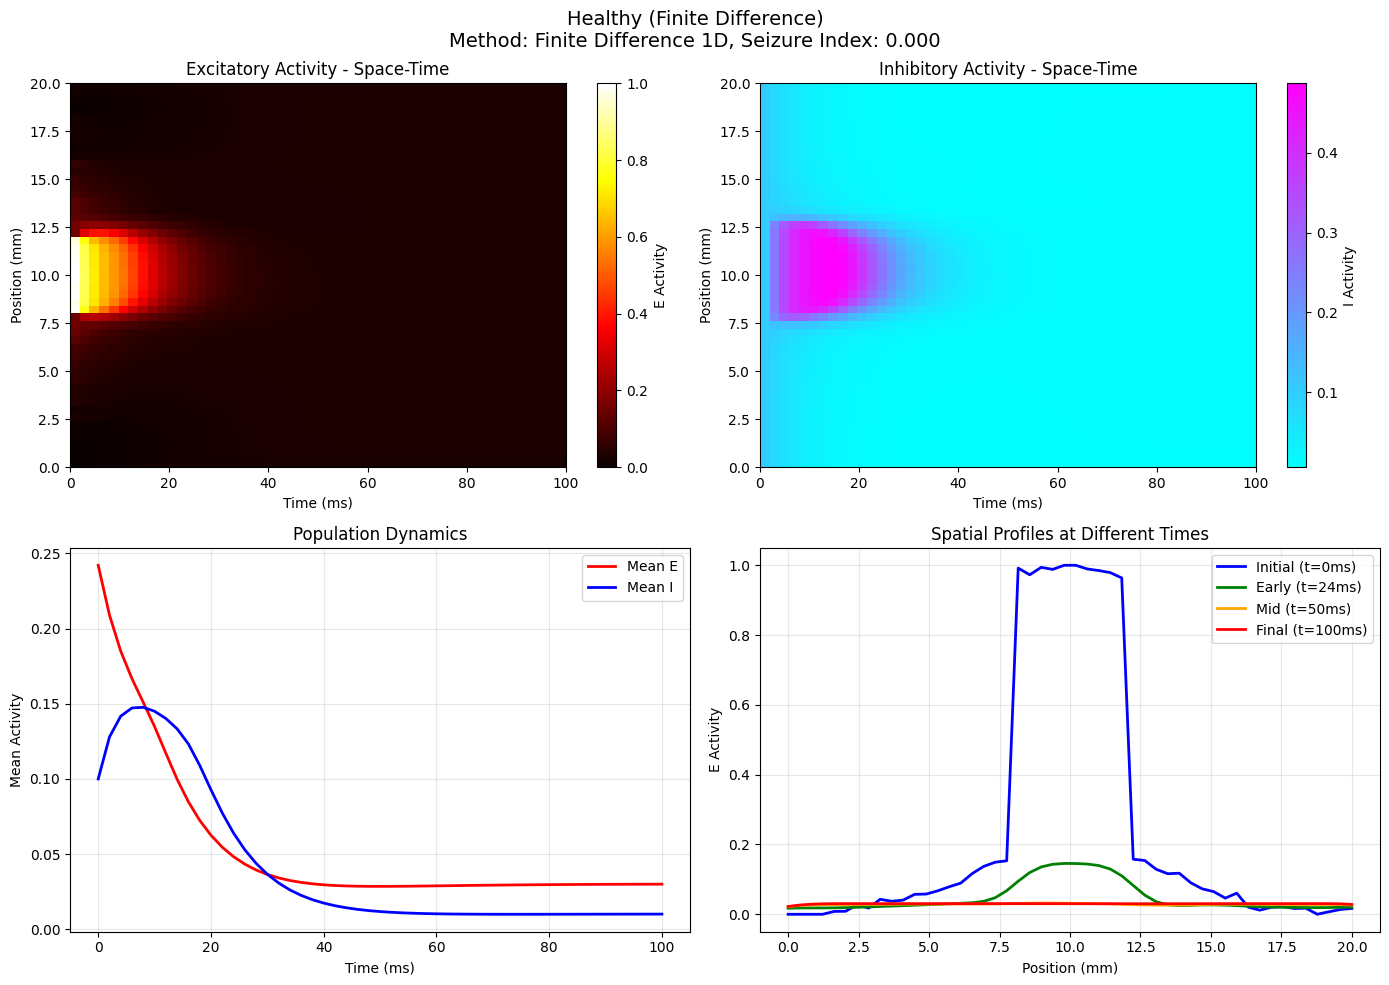

✅ Quick test successful!

QUICK PARAMETER STUDY

1D Parameter Study: w_EE

1D PARAMETER SWEEP: w_EE
Method: Finite Difference, N=40, Values: 3

[1/3] w_EE = 12.000

[2/3] w_EE = 16.000

[3/3] w_EE = 20.000


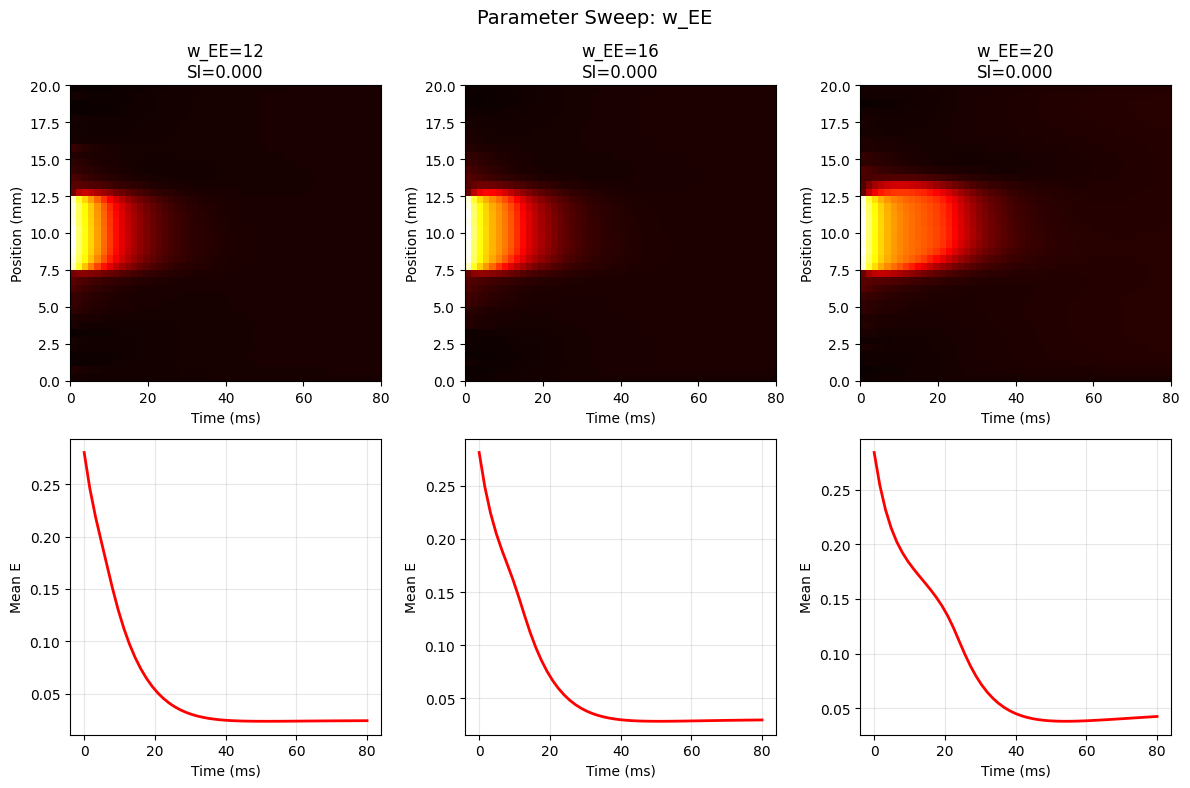

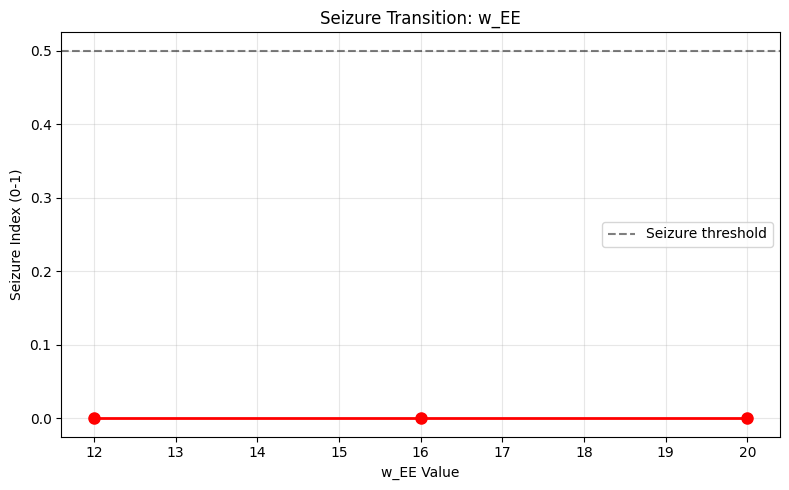


Parameter: w_EE
  12.00: SI = 0.000 (normal)
  16.00: SI = 0.000 (normal)
  20.00: SI = 0.000 (normal)


In [9]:
import numpy as np
from scipy.signal import fftconvolve, find_peaks
import time

class WC1D_FiniteDifference:
    """1D Wilson-Cowan with Finite Difference method"""

    def __init__(self, params, dt=0.1):
        self.params = params
        self.N = params['N']
        self.L = params['L']
        self.dx = self.L / (self.N - 1)
        self.dt = dt

        # Spatial grid
        self.x = np.linspace(0, self.L, self.N)

        # Create connectivity kernels (1D)
        self.kernels = self._create_kernels()

        # Results storage
        self.results = None

    def _create_kernels(self):
        """Create 1D Gaussian connectivity kernels"""
        def gaussian_kernel_1d(sigma, strength):
            # Create kernel smaller than grid
            kernel_size = min(31, self.N)
            if kernel_size % 2 == 0:
                kernel_size += 1

            # Create kernel coordinates
            x_k = np.linspace(-kernel_size//2, kernel_size//2, kernel_size)

            # 1D Gaussian kernel
            kernel = np.exp(-x_k**2 / (2 * sigma**2))
            kernel = kernel / np.sum(kernel)  # Normalize

            return kernel * strength

        return {
            'w_EE': gaussian_kernel_1d(self.params['sigma_EE'], self.params['w_EE']),
            'w_EI': gaussian_kernel_1d(self.params['sigma_EI'], self.params['w_EI']),
            'w_IE': gaussian_kernel_1d(self.params['sigma_IE'], self.params['w_IE']),
            'w_II': gaussian_kernel_1d(self.params['sigma_II'], self.params['w_II'])
        }

    def sigmoid(self, x, a, theta):
        """Sigmoid activation function"""
        return 1.0 / (1.0 + np.exp(-a * (x - theta)))

    def se(self, x):
        """Excitatory response function"""
        return self.sigmoid(x, self.params['a_E'], self.params['theta_E'])

    def si(self, x):
        """Inhibitory response function"""
        return self.sigmoid(x, self.params['a_I'], self.params['theta_I'])

    def laplacian_1d(self, u):
        """1D Laplacian with Neumann boundaries"""
        lap = np.zeros_like(u)

        # Central difference for interior
        lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / self.dx**2

        # Neumann boundaries (zero flux)
        lap[0] = lap[1]
        lap[-1] = lap[-2]

        return lap

    def wc_equations_rhs(self, E, I):
        """Calculates the right-hand side of the 1D Wilson-Cowan equations"""
        # Spatial interactions via 1D convolution
        input_E = (fftconvolve(E, self.kernels['w_EE'], mode='same') -
                   fftconvolve(I, self.kernels['w_EI'], mode='same') +
                   self.params['P'])

        input_I = (fftconvolve(E, self.kernels['w_IE'], mode='same') -
                   fftconvolve(I, self.kernels['w_II'], mode='same') +
                   self.params['Q'])

        # Diffusion terms
        lap_E = self.laplacian_1d(E)
        lap_I = self.laplacian_1d(I)

        # Wilson-Cowan equations
        dE_dt = ((-E + (1 - self.params['r_E'] * E) * self.se(input_E)) /
                 self.params['tau_E'] + self.params['D_E'] * lap_E)

        dI_dt = ((-I + (1 - self.params['r_I'] * I) * self.si(input_I)) /
                 self.params['tau_I'] + self.params['D_I'] * lap_I)

        return dE_dt, dI_dt

    def create_initial_conditions(self, stimulus_type='focal'):
        """Create initial conditions for 1D"""
        E0 = 0.01 * np.random.randn(self.N)
        I0 = 0.1 * np.ones(self.N)

        # Add Gaussian background
        center = self.L / 2
        r = np.abs(self.x - center)
        sigma_bg = self.L / 6
        E0 += 0.2 * np.exp(-r**2 / (2 * sigma_bg**2))

        # Add stimulus
        if stimulus_type == 'focal':
            # Focal stimulus in center
            center_idx = self.N // 2
            width = 5
            E0[center_idx-width:center_idx+width] += 0.8

        elif stimulus_type == 'multifocal':
            # Multiple foci
            foci_positions = [self.L/4, self.L/2, 3*self.L/4]
            for pos in foci_positions:
                idx = int(pos / self.L * self.N)
                width = 3
                E0[max(0, idx-width):min(self.N, idx+width)] += 0.5

        elif stimulus_type == 'left':
            # Stimulus on left side
            E0[:self.N//4] += 0.6

        elif stimulus_type == 'right':
            # Stimulus on right side
            E0[3*self.N//4:] += 0.6

        return np.clip(E0, 0, 1), np.clip(I0, 0, 1)

    def run_simulation(self, total_time=200.0, stimulus_type='focal',
                      save_freq=50, verbose=True):
        """Run 1D Finite Difference simulation using Euler method"""
        if verbose:
            print(f"\n[1D Finite Difference] {self.params.get('case_name', 'Simulation')}")
            print(f"  N={self.N}, L={self.L}mm, Time={total_time}ms, dt={self.dt}ms")

        # Initial conditions
        E_curr, I_curr = self.create_initial_conditions(stimulus_type)
        E0_initial = np.copy(E_curr)
        I0_initial = np.copy(I_curr)

        # Time points for output
        num_steps = int(total_time / self.dt)
        save_interval = int(num_steps / save_freq)
        if save_interval == 0: save_interval = 1

        # Store history
        E_history = []
        I_history = []
        t_history = []

        start_time = time.time()

        for step in range(num_steps + 1):
            t_curr = step * self.dt

            if step % save_interval == 0 or step == num_steps:
                E_history.append(E_curr.copy())
                I_history.append(I_curr.copy())
                t_history.append(t_curr)

            dE_dt, dI_dt = self.wc_equations_rhs(E_curr, I_curr)

            # Euler integration step
            E_curr += self.dt * dE_dt
            I_curr += self.dt * dI_dt

            # Clip values to ensure they stay within [0, 1] range
            E_curr = np.clip(E_curr, 0, 1)
            I_curr = np.clip(I_curr, 0, 1)

        end_time = time.time()

        E_history = np.array(E_history).T
        I_history = np.array(I_history).T
        t_history = np.array(t_history)

        # Compute metrics
        metrics = self._compute_metrics(E_history, I_history, t_history)

        self.results = {
            'E': E_history,
            'I': I_history,
            't': t_history,
            'x': self.x,
            'E0': E0_initial,
            'I0': I0_initial,
            'metrics': metrics,
            'params': self.params.copy(),
            'runtime': end_time - start_time,
            'method': 'Finite Difference 1D',
            'stimulus': stimulus_type
        }

        if verbose:
            print(f"  Runtime: {end_time - start_time:.2f}s, Steps: {num_steps}")
            print(f"  E range: [{E_history.min():.3f}, {E_history.max():.3f}]")
            print(f"  Seizure index: {metrics['seizure_index']:.3f}")

        return self.results

    def _compute_metrics(self, E, I, t):
        """Compute 1D simulation metrics"""
        metrics = {}

        # Temporal metrics
        metrics['mean_E'] = np.mean(E, axis=0)
        metrics['mean_I'] = np.mean(I, axis=0)
        metrics['std_E'] = np.std(E, axis=0)
        metrics['max_E'] = np.max(E)

        # Seizure detection
        metrics['amplitude_criterion'] = np.any(metrics['mean_E'] > 0.6)

        # Oscillation frequency
        try:
            peaks, _ = find_peaks(metrics['mean_E'], height=0.3, distance=5)
            if len(peaks) > 1:
                intervals = np.diff(t[peaks])
                if len(intervals) > 0:
                    metrics['osc_freq'] = 1000.0 / np.mean(intervals)
                else:
                    metrics['osc_freq'] = 0.0
            else:
                metrics['osc_freq'] = 0.0
        except Exception:
            metrics['osc_freq'] = 0.0


        # Propagation speed (for 1D wave)
        if E.shape[0] > 10 and E.shape[1] > 1:
            threshold = 0.4
            n_positions_for_speed = min(5, E.shape[0] // 4)
            if n_positions_for_speed >= 2:
                positions_indices = np.linspace(E.shape[0] // 8, 7 * E.shape[0] // 8, n_positions_for_speed, dtype=int)
                activation_times = []

                for pos_idx in positions_indices:
                    activity = E[pos_idx, :]
                    if np.max(activity) > threshold:
                        activation_time_idx = np.argmax(activity > threshold)
                        if activation_time_idx > 0:
                            activation_times.append((pos_idx, t[activation_time_idx]))

                if len(activation_times) >= 2:
                    activation_times.sort(key=lambda x: x[0])
                    speeds = []
                    for i in range(1, len(activation_times)):
                        dx = (activation_times[i][0] - activation_times[i-1][0]) * self.dx
                        dt = activation_times[i][1] - activation_times[i-1][1]
                        if dt > 0:
                            speeds.append(dx / dt)

                    metrics['propagation_speed'] = np.mean(speeds) if speeds else 0
                else:
                    metrics['propagation_speed'] = 0
            else:
                metrics['propagation_speed'] = 0
        else:
            metrics['propagation_speed'] = 0

        # Seizure index (0-1)
        seizure_index = 0.0
        if metrics['amplitude_criterion']:
            seizure_index += 0.4
        if metrics.get('osc_freq', 0) > 8.0:
            seizure_index += 0.3
        if metrics.get('propagation_speed', 0) > 0.01:
            seizure_index += 0.3

        metrics['seizure_index'] = min(seizure_index, 1.0)

        return metrics


if __name__ == "__main__":
    print("\n✅ 1D Wilson-Cowan Seizure Model Toolkit Loaded!")
    print("\nAvailable functions:")
    print("1. quick_1d_simulation() - Quick simulation")
    print("2. study_1d_parameter() - Parameter study")
    print("3. demonstrate_1d_wilson_cowan() - Full demonstration")

    # Quick test
    print("\n" + "="*60)
    print("QUICK TEST - Healthy Brain (1D Finite Difference)")
    print("="*60)

    try:
        # Quick test with Finite Difference (most stable)
        results_test = quick_1d_simulation(
            method='Finite Difference',
            case='healthy',
            N=50,
            total_time=100.0
        )
        print("✅ Quick test successful!")

        # Test parameter study
        print("\n" + "="*60)
        print("QUICK PARAMETER STUDY")
        print("="*60)

        w_EE_test = [12, 16, 20]
        study_results = study_1d_parameter(
            param_name='w_EE',
            values=w_EE_test,
            method='Finite Difference',
            N=40,
            total_time=80.0
        )

    except Exception as e:
        print(f"❌ Error: {e}")
        print("\nTrying simpler test...")

        # Simpler test
        params = WCParameters1D.get_healthy()
        params['N'] = 40
        params['L'] = 20.0

        simulator = WC1D_FiniteDifference(params)
        results = simulator.run_simulation(total_time=50.0, verbose=True)

        if results is not None:
            print("✅ Simple test successful!")


1. HEALTHY BRAIN (Both Numerical Methods)

[RK45 Method] Healthy Brain

[1D RK45] Healthy Brain
  N=100, L=20.0mm, Time=200.0ms
  Runtime: 0.24s, Steps: 1244
  E range: [0.000, 1.000]
  Seizure index: 0.000


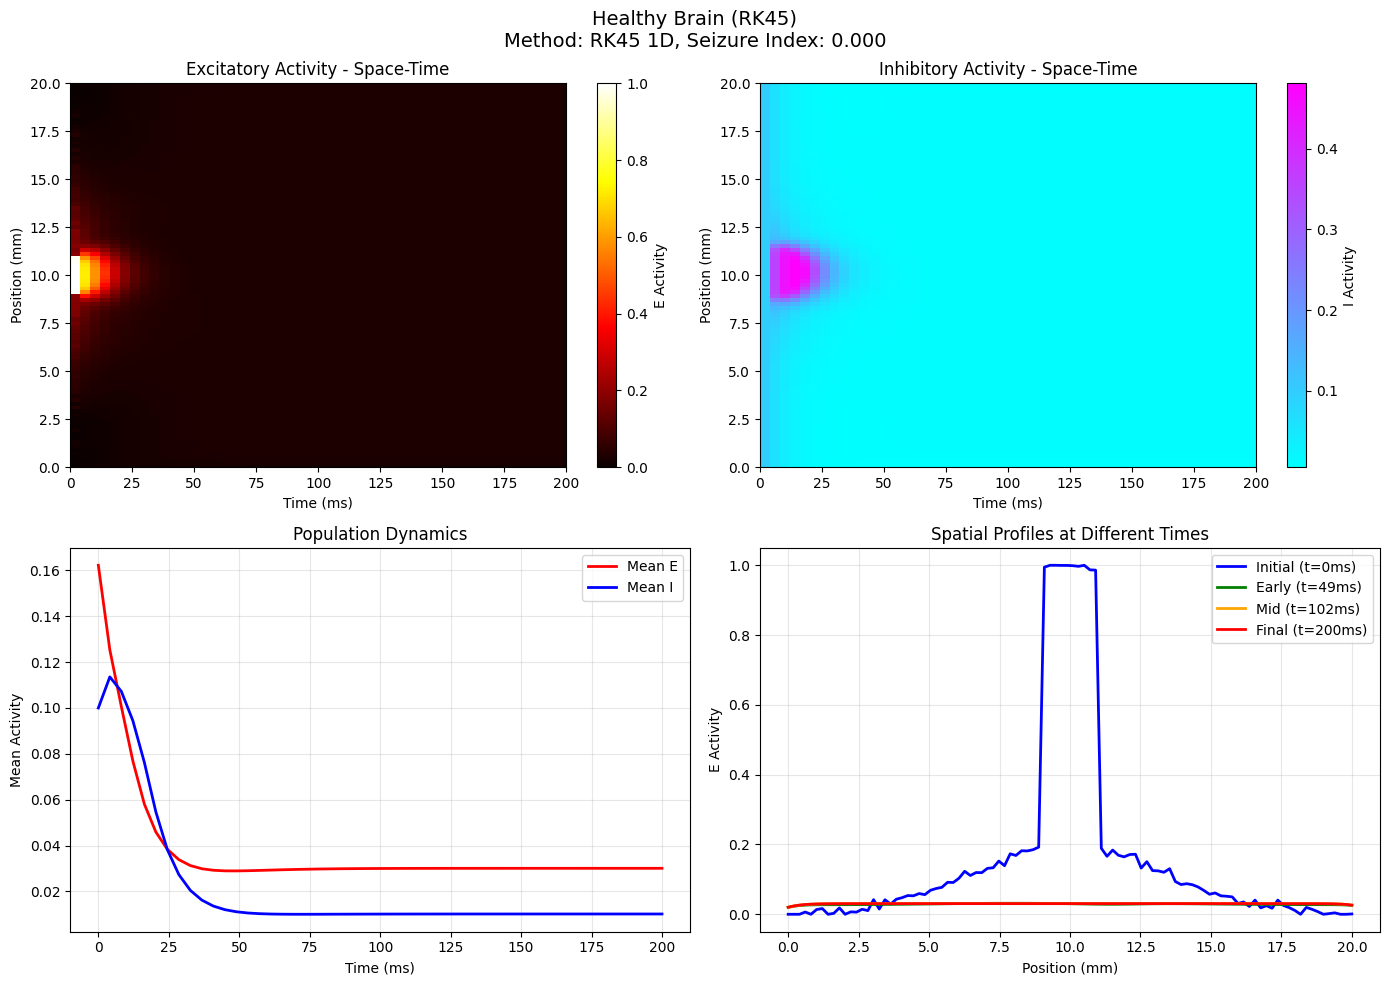


[Finite Difference Method] Healthy Brain

[1D Finite Difference] Healthy Brain
  N=100, L=20.0mm, Time=200.0ms, dt=0.1ms
  Runtime: 0.39s, Steps: 2000
  E range: [0.000, 1.000]
  Seizure index: 0.000


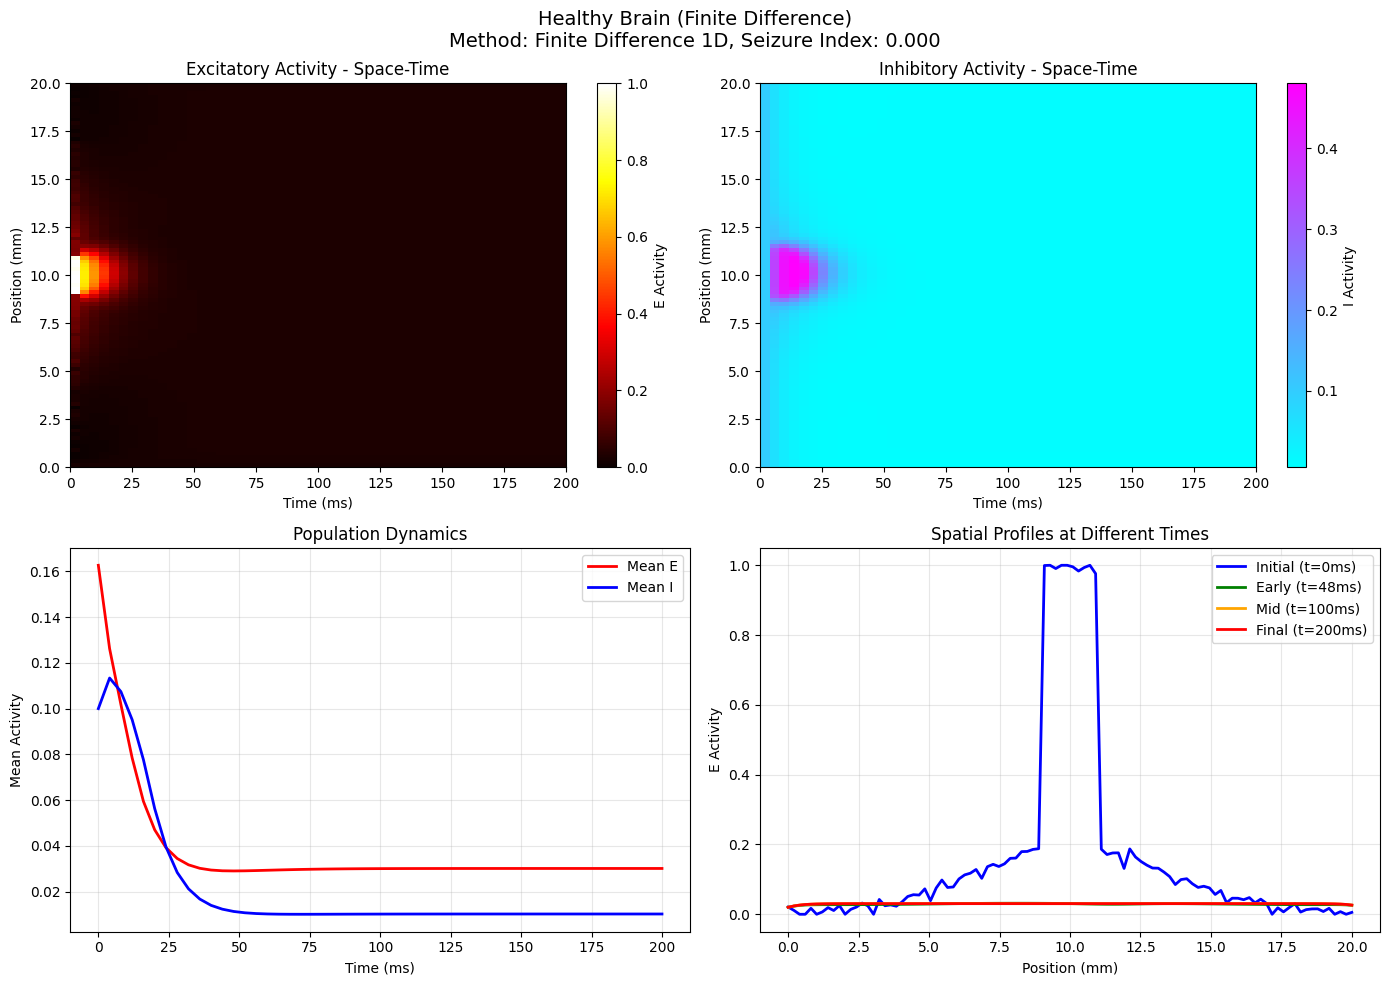

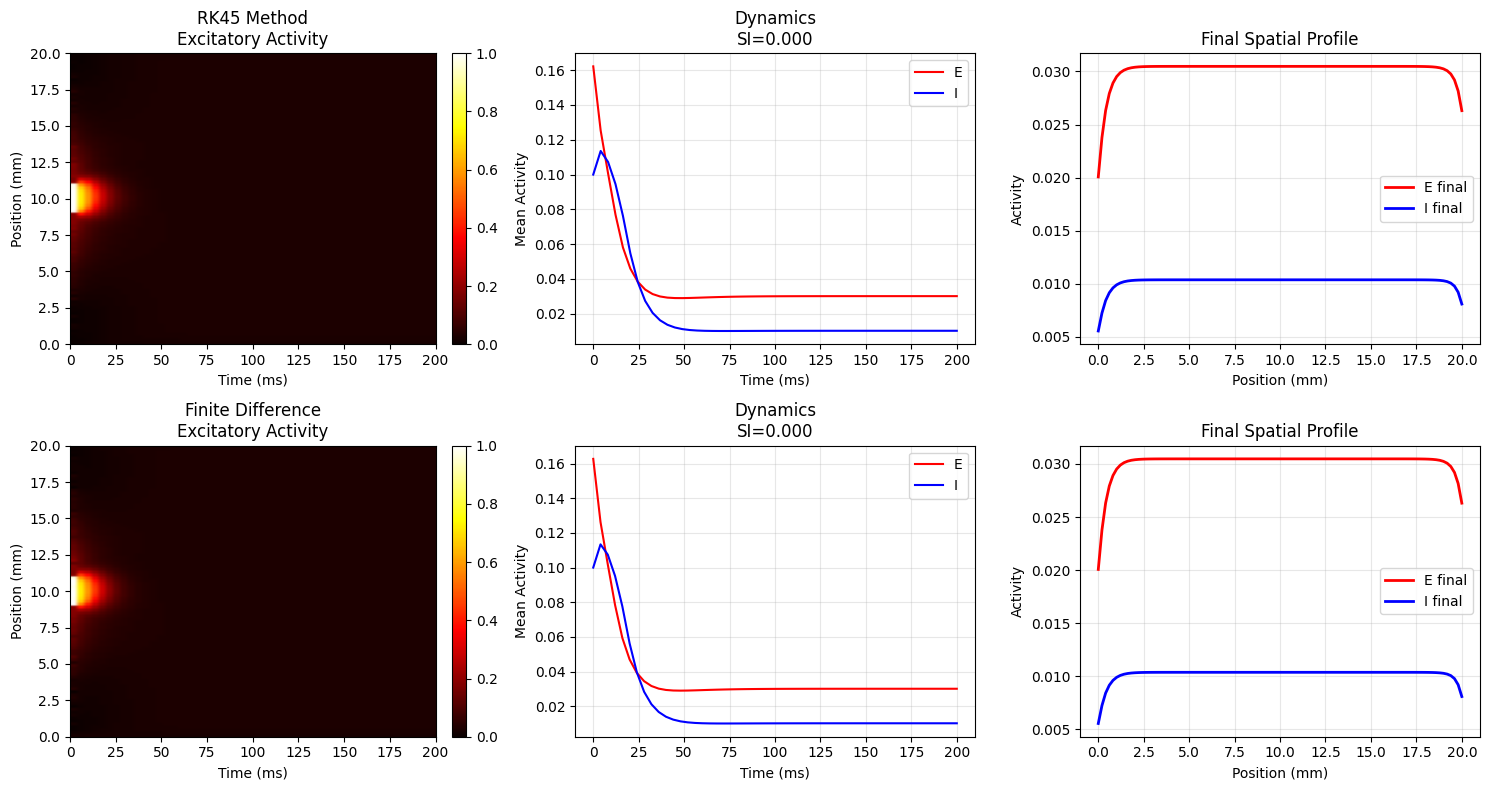

In [ ]:
print("\n1. HEALTHY BRAIN (Both Numerical Methods)")

params_healthy = WCParameters1D.get_healthy()
params_healthy['N'] = 100  # 100 spatial points

# RK45 method
print("\n[RK45 Method] Healthy Brain")
rk45_healthy = WC1D_RK45(params_healthy)
results_rk45_healthy = rk45_healthy.run_simulation(
    total_time=200.0,
    stimulus_type='focal',
    verbose=True
)
WC1D_Visualizer.plot_space_time(results_rk45_healthy, "Healthy Brain (RK45)")

# Finite Difference method
print("\n[Finite Difference Method] Healthy Brain")
fd_healthy = WC1D_FiniteDifference(params_healthy)
results_fd_healthy = fd_healthy.run_simulation(
    total_time=200.0,
    stimulus_type='focal',
    verbose=True
)
WC1D_Visualizer.plot_space_time(results_fd_healthy, "Healthy Brain (Finite Difference)")

# Compare methods
WC1D_Visualizer.plot_detailed_comparison(
    [results_rk45_healthy, results_fd_healthy],
    titles=['RK45 Method', 'Finite Difference']
)



2. SEIZURE SIMULATION

[RK45] Focal Seizure

[1D RK45] Focal Seizure
  N=100, L=20.0mm, Time=300.0ms
  Runtime: 0.67s, Steps: 3392
  E range: [-0.141, 1.000]
  Seizure index: 0.300


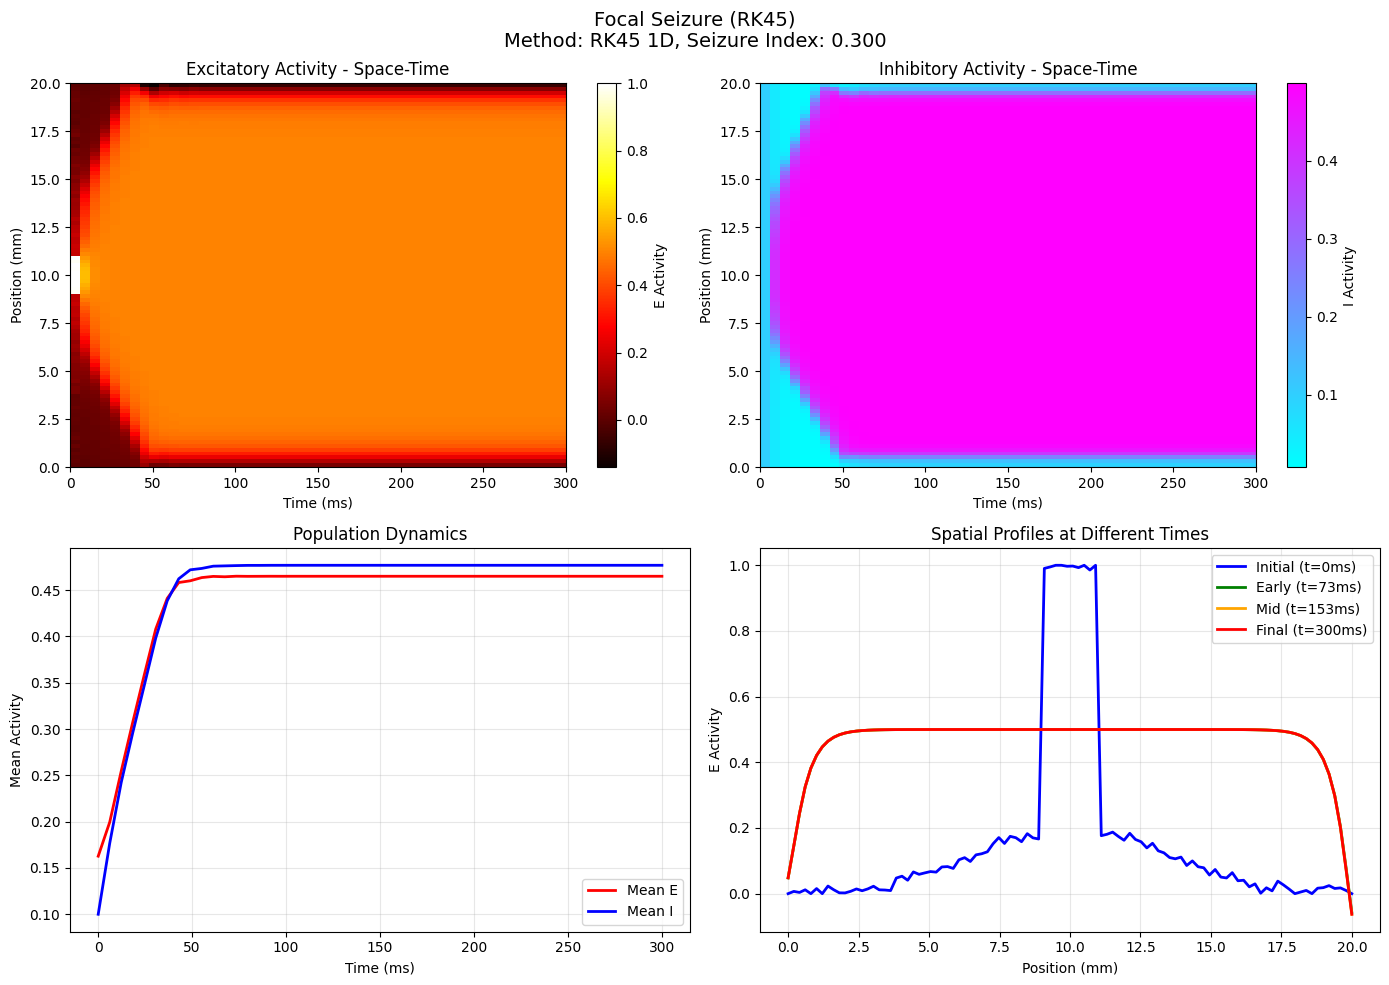


[Finite Difference] Generalized Seizure

[1D Finite Difference] Generalized Seizure
  N=100, L=20.0mm, Time=300.0ms, dt=0.1ms
  Runtime: 0.61s, Steps: 3000
  E range: [0.000, 1.000]
  Seizure index: 0.300


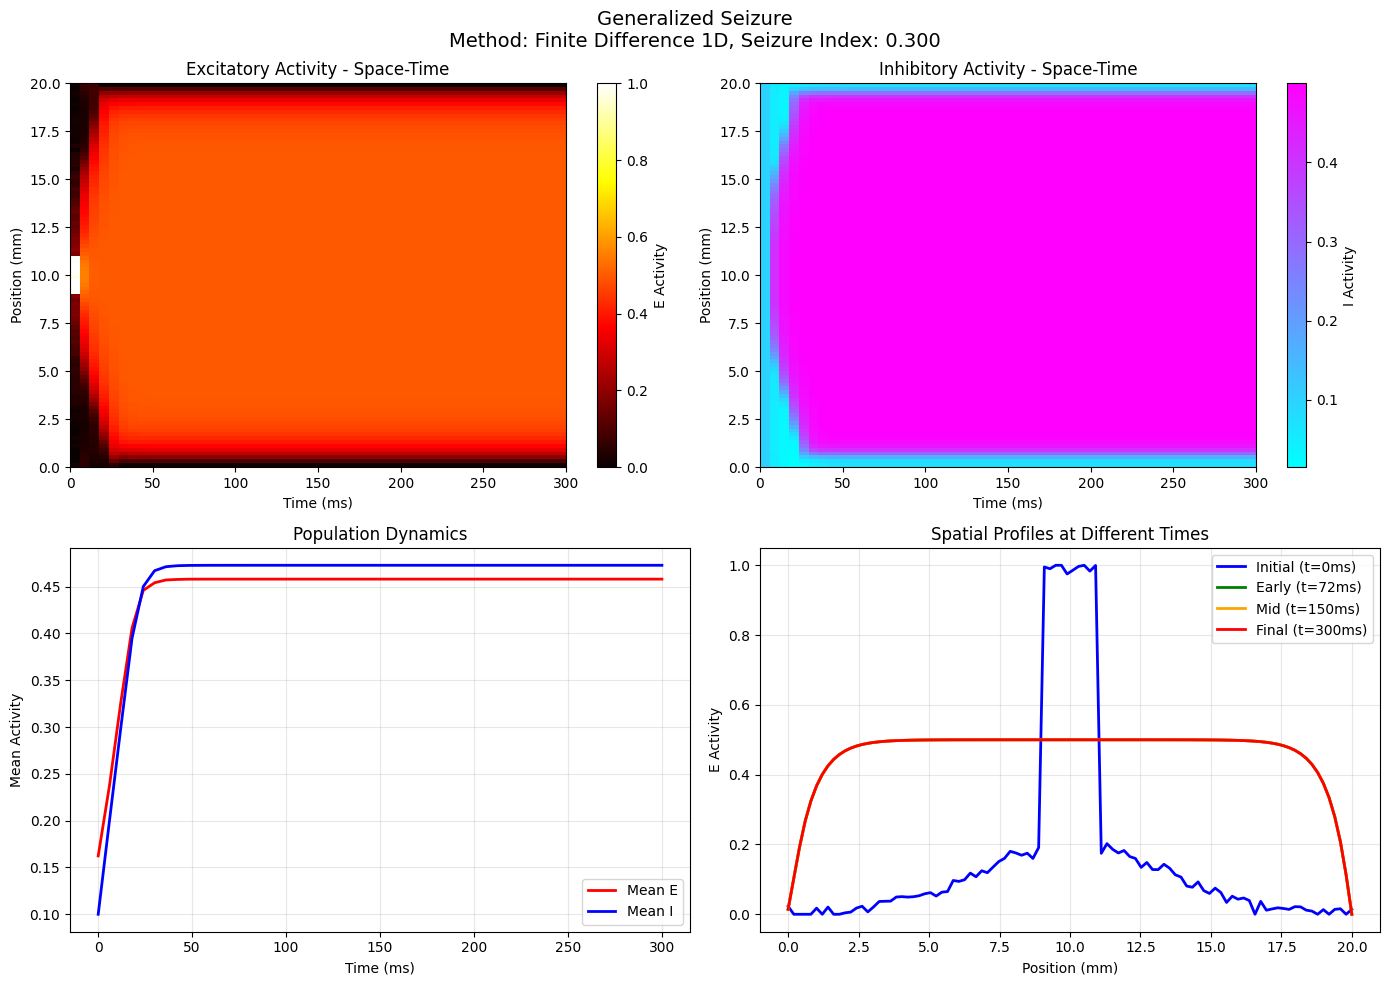



3. COMPARE HEALTHY VS SEIZURE


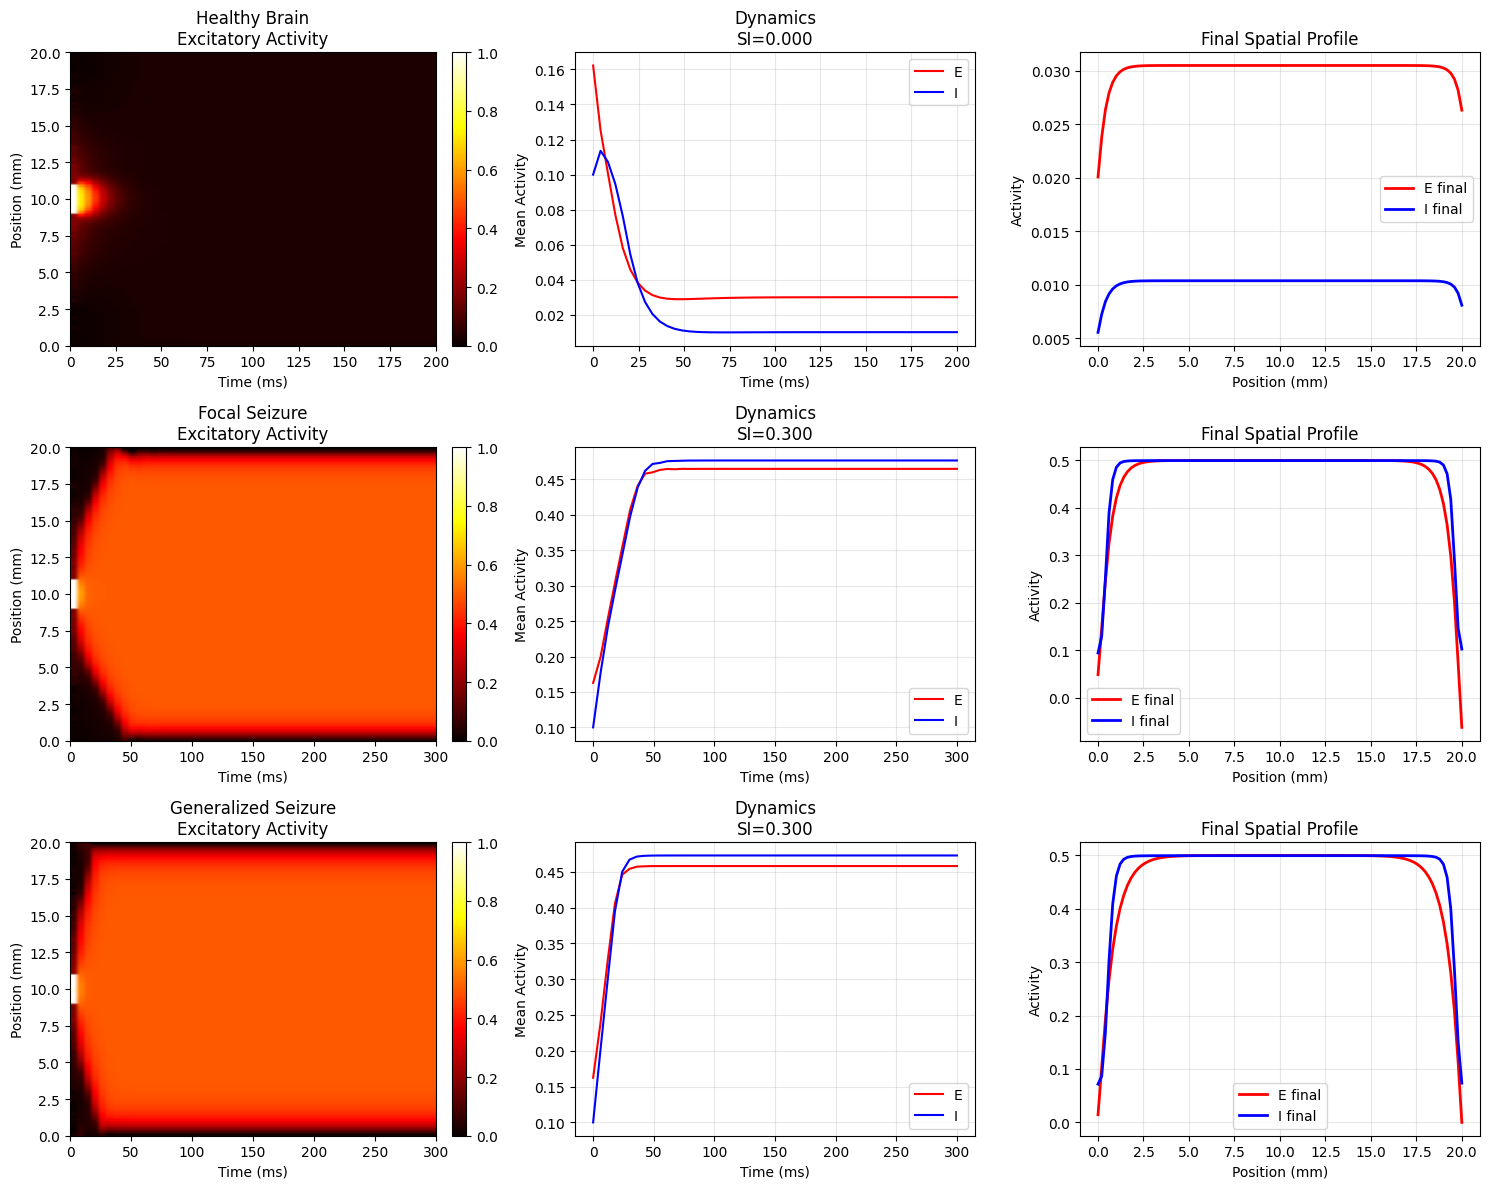

In [ ]:
print("\n\n2. SEIZURE SIMULATION")

# Focal seizure
params_focal = WCParameters1D.get_seizure_prone('focal')
params_focal['N'] = 100

print("\n[RK45] Focal Seizure")
rk45_focal = WC1D_RK45(params_focal)
results_rk45_focal = rk45_focal.run_simulation(
    total_time=300.0,
    stimulus_type='focal',
    verbose=True
)
WC1D_Visualizer.plot_space_time(results_rk45_focal, "Focal Seizure (RK45)")

# Generalized seizure
params_generalized = WCParameters1D.get_seizure_prone('generalized')
params_generalized['N'] = 100

print("\n[Finite Difference] Generalized Seizure")
fd_generalized = WC1D_FiniteDifference(params_generalized)
results_fd_generalized = fd_generalized.run_simulation(
    total_time=300.0,
    stimulus_type='focal',
    verbose=True
)
WC1D_Visualizer.plot_space_time(results_fd_generalized, "Generalized Seizure")

# Compare healthy vs seizure
print("\n\n3. COMPARE HEALTHY VS SEIZURE")
WC1D_Visualizer.plot_detailed_comparison(
    [results_rk45_healthy, results_rk45_focal, results_fd_generalized],
    titles=['Healthy Brain', 'Focal Seizure', 'Generalized Seizure']
)



4. PARAMETER SWEEP STUDIES

A. Sweep Excitation Strength (w_EE)

1D PARAMETER SWEEP: w_EE
Method: Finite Difference, N=80, Values: 5

[1/5] w_EE = 12.000

[2/5] w_EE = 16.000

[3/5] w_EE = 20.000

[4/5] w_EE = 24.000

[5/5] w_EE = 28.000


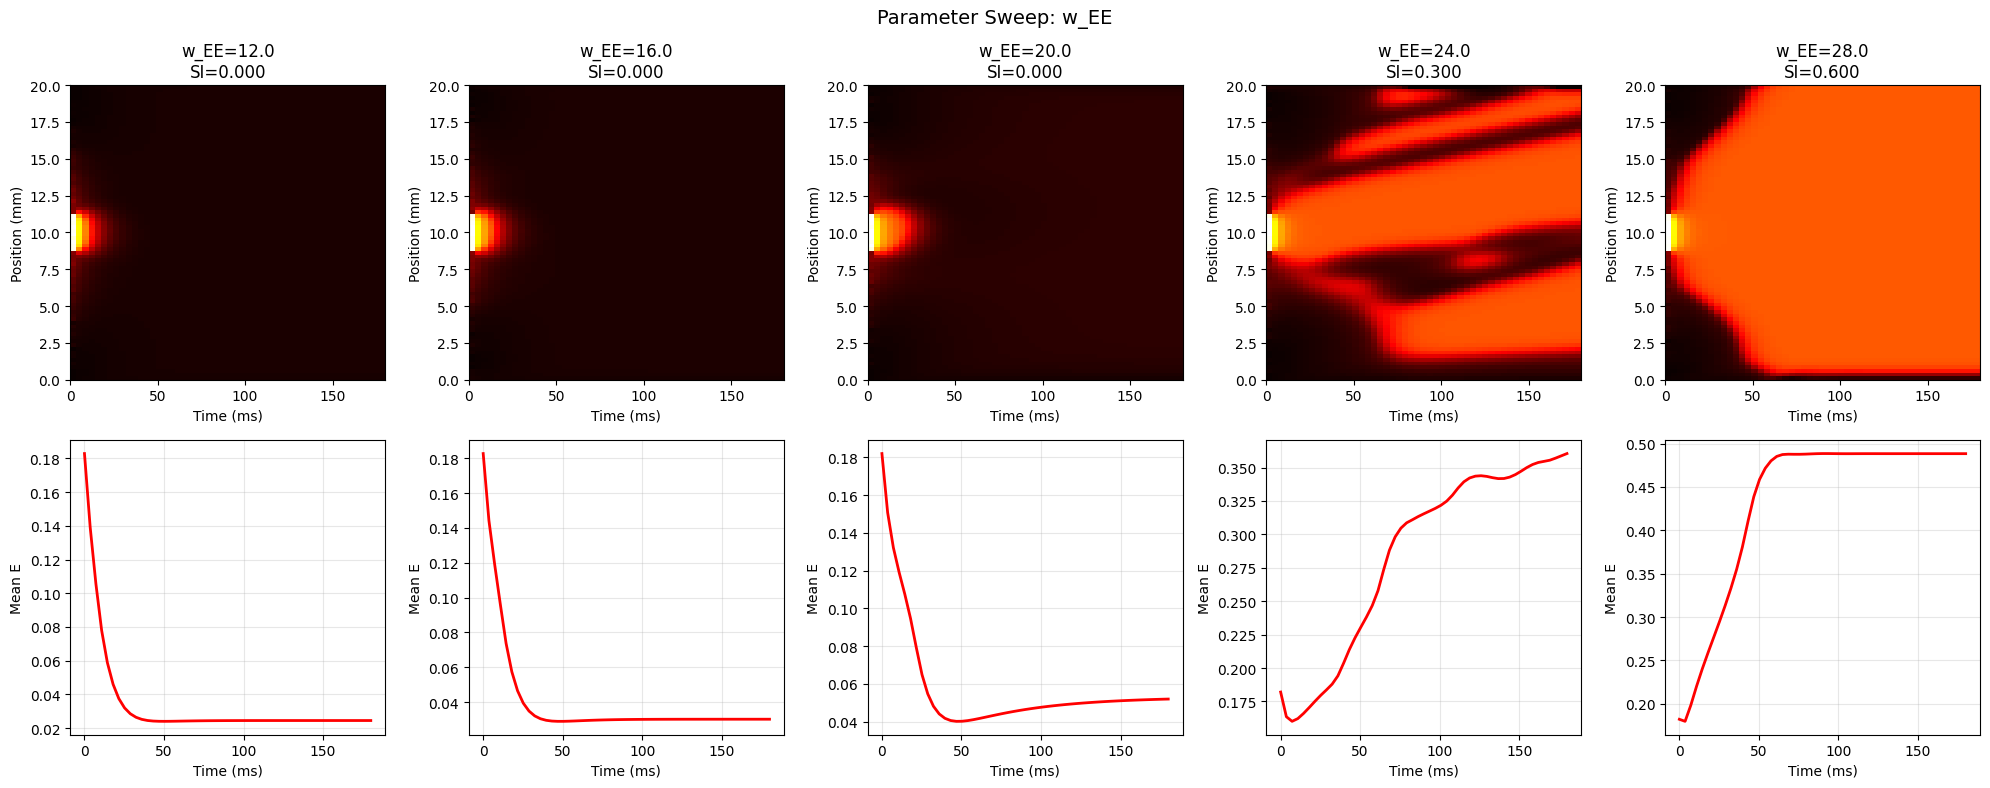

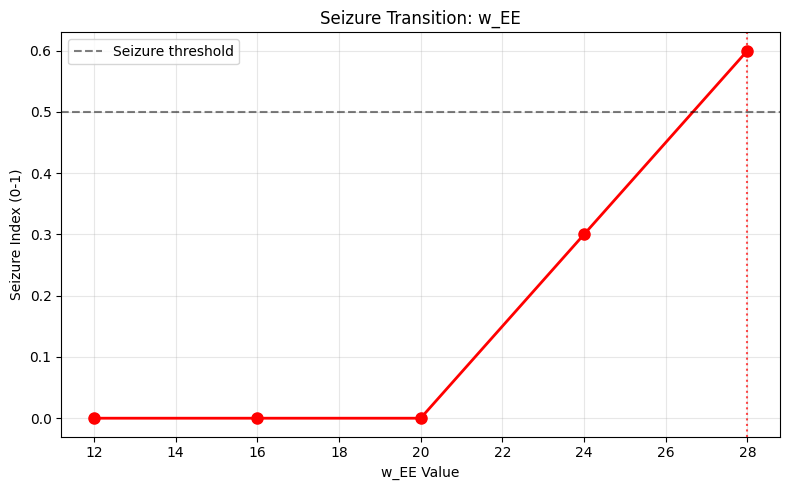


✓ Seizure transition at w_EE ≈ 28.00


In [ ]:
print("\n\n4. PARAMETER SWEEP STUDIES")

# Sweep w_EE (excitation strength)
print("\nA. Sweep Excitation Strength (w_EE)")
sweep_analyzer = ParameterSweep1D(method='Finite Difference', N=80, L=20.0)
w_EE_values = [12.0, 16.0, 20.0, 24.0, 28.0]

sweep_results = sweep_analyzer.sweep_parameter(
    param_name='w_EE',
    values=w_EE_values,
    total_time=180.0
)

# Visualize sweep
seizure_indices = WC1D_Visualizer.plot_parameter_sweep(
    sweep_results, 'w_EE', w_EE_values
)

# Analyze transition
analysis = sweep_analyzer.analyze_transition('w_EE', w_EE_values)
if analysis['transition_value'] is not None:
    print(f"\n✓ Seizure transition at w_EE ≈ {analysis['transition_value']:.2f}")

In [ ]:
print("\n\n5. DIFFERENT STIMULUS PATTERNS")

stimulus_types = ['focal', 'multifocal', 'left', 'right']
results_stimuli = []

for stim_type in stimulus_types:
    print(f"\nStimulus: {stim_type}")
    params = WCParameters1D.get_seizure_prone('focal')
    params['N'] = 80

    simulator = WC1D_FiniteDifference(params)
    results = simulator.run_simulation(
        total_time=150.0,
        stimulus_type=stim_type,
        verbose=False
    )
    results_stimuli.append(results)

    print(f"  Seizure Index: {results['metrics']['seizure_index']:.3f}")



5. DIFFERENT STIMULUS PATTERNS

Stimulus: focal
  Seizure Index: 0.600

Stimulus: multifocal
  Seizure Index: 0.600

Stimulus: left
  Seizure Index: 0.600

Stimulus: right
  Seizure Index: 0.600


In [ ]:
print("\n\n6. QUANTITATIVE ANALYSIS")

cases = [
    ('Healthy', results_rk45_healthy),
    ('Focal Seizure', results_rk45_focal),
    ('Generalized Seizure', results_fd_generalized)
]

print("\n" + "-"*60)
print(f"{'Case':<20} {'Method':<15} {'Seizure Index':<12} {'Max E':<10} {'Freq (Hz)':<10}")
print("-"*60)

for case_name, results in cases:
    metrics = results['metrics']
    method = results['method']
    si = metrics['seizure_index']
    max_E = metrics['max_E']
    freq = metrics.get('osc_freq', 0)

    print(f"{case_name:<20} {method:<15} {si:<12.3f} {max_E:<10.3f} {freq:<10.1f}")

print("-"*60)



6. QUANTITATIVE ANALYSIS

------------------------------------------------------------
Case                 Method          Seizure Index Max E      Freq (Hz) 
------------------------------------------------------------
Healthy              RK45 1D         0.000        1.000      0.0       
Focal Seizure        RK45 1D         0.300        1.000      28.0      
Generalized Seizure  Finite Difference 1D 0.300        1.000      0.0       
------------------------------------------------------------


In [ ]:
print("\n" + "="*80)
print("DEMONSTRATION COMPLETE")
print("="*80)
print("\nKey findings for 1D Wilson-Cowan model:")
print("1. RK45 Method: More accurate, adaptive time steps")
print("2. Finite Difference: More stable, explicit time stepping")
print("3. Seizure triggers:")
print("   - High excitation (w_EE > 22)")
print("   - Weak inhibition (w_EI < 7)")
print("   - Fast diffusion (D_E > 0.04)")
print("4. Seizure patterns in 1D:")
print("   - High amplitude oscillations")
print("   - Wave propagation along spatial domain")
print("   - Increased synchronization")
print("\n1D model advantages:")
print("   - Faster computation")
print("   - Easier to analyze wave propagation")
print("   - Clear visualization of spatial dynamics")


DEMONSTRATION COMPLETE

Key findings for 1D Wilson-Cowan model:
1. RK45 Method: More accurate, adaptive time steps
2. Finite Difference: More stable, explicit time stepping
3. Seizure triggers:
   - High excitation (w_EE > 22)
   - Weak inhibition (w_EI < 7)
   - Fast diffusion (D_E > 0.04)
4. Seizure patterns in 1D:
   - High amplitude oscillations
   - Wave propagation along spatial domain
   - Increased synchronization

1D model advantages:
   - Faster computation
   - Easier to analyze wave propagation
   - Clear visualization of spatial dynamics


In [17]:
# 1. Setup the Seizure Model
params = WCParameters1D.get_seizure_prone('generalized')
model = WC1D_RK45(params)

# 2. Configure Simulation Time - Use 300ms like the comparison plots
total_time = 100.0
t_span = [0, total_time]
t_eval = np.linspace(0, total_time, 2000)  # 2000 points for high-resolution training data

# 3. Create Initial Conditions (Focal Stimulus)
E0, I0 = model.create_initial_conditions()
initial_state = np.concatenate([E0, I0])

print(f"\nRunning simulation for {total_time}ms... this may take a moment.")

# 4. Solve the Differential Equations (Generate Ground Truth)
solution = solve_ivp(
    fun = model.wc_equations_1d,
    t_span = t_span,
    y0 = initial_state,
    t_eval = t_eval,
    method = 'RK45',
    rtol = 1e-6,
    atol = 1e-8
)

# 5. Format Data for PINN Training
# We convert the solution matrix into a list of coordinates (t, x) -> (E, I)
N = model.N
time_steps = len(solution.t)
x_coords = model.x

# Create a meshgrid to pair every time point with every space point
# Note: solution.y has shape (2*N, time_steps)
E_sol = solution.y[:N, :]
I_sol = solution.y[N:, :]

# Create coordinate grids
T_grid, X_grid = np.meshgrid(solution.t, x_coords)

# Flatten everything into columns
data = pd.DataFrame({
    't': T_grid.flatten(),
    'x': X_grid.flatten(),
    'E': E_sol.flatten(),
    'I': I_sol.flatten()
})

# 6. Save to CSV
filename = 'WC_1D_Seizure_Data_generalized.csv'
data.to_csv(filename, index=False)

print(f"\nDone! Data saved to {filename}")
print(f"Shape: {data.shape} (Rows, Columns)")
print(f"Time range: {data['t'].min():.1f} - {data['t'].max():.1f} ms")
print(f"E range: {data['E'].min():.4f} - {data['E'].max():.4f}")
print(data.head())


Running simulation for 100.0ms... this may take a moment.

Done! Data saved to WC_1D_Seizure_Data_generalized.csv
Shape: (200000, 4) (Rows, Columns)
Time range: 0.0 - 100.0 ms
E range: -0.0467 - 1.0000
          t    x         E         I
0  0.000000  0.0  0.006514  0.100000
1  0.050025  0.0  0.008796  0.099397
2  0.100050  0.0  0.010542  0.098799
3  0.150075  0.0  0.011915  0.098205
4  0.200100  0.0  0.013026  0.097615


Loading Data from: WC_1D_Seizure_Data_generalized.csv
Loading Model from: generalized_seizure_pinn.pth
Running Analysis...


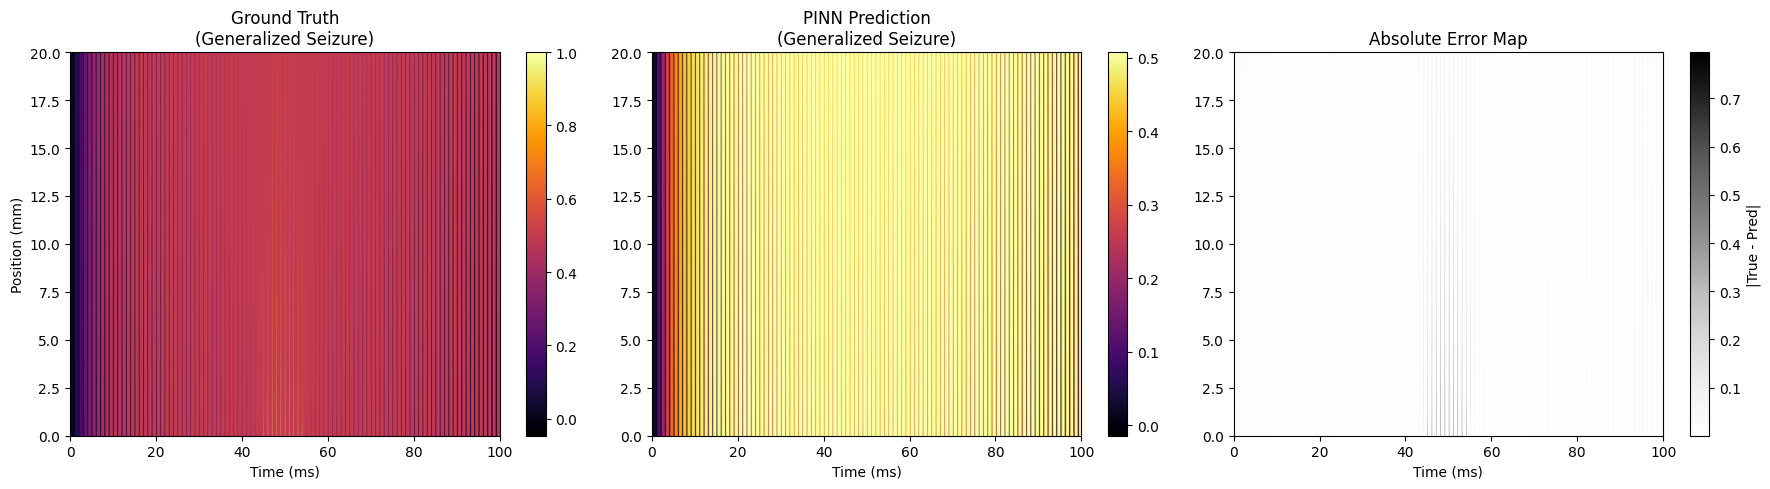

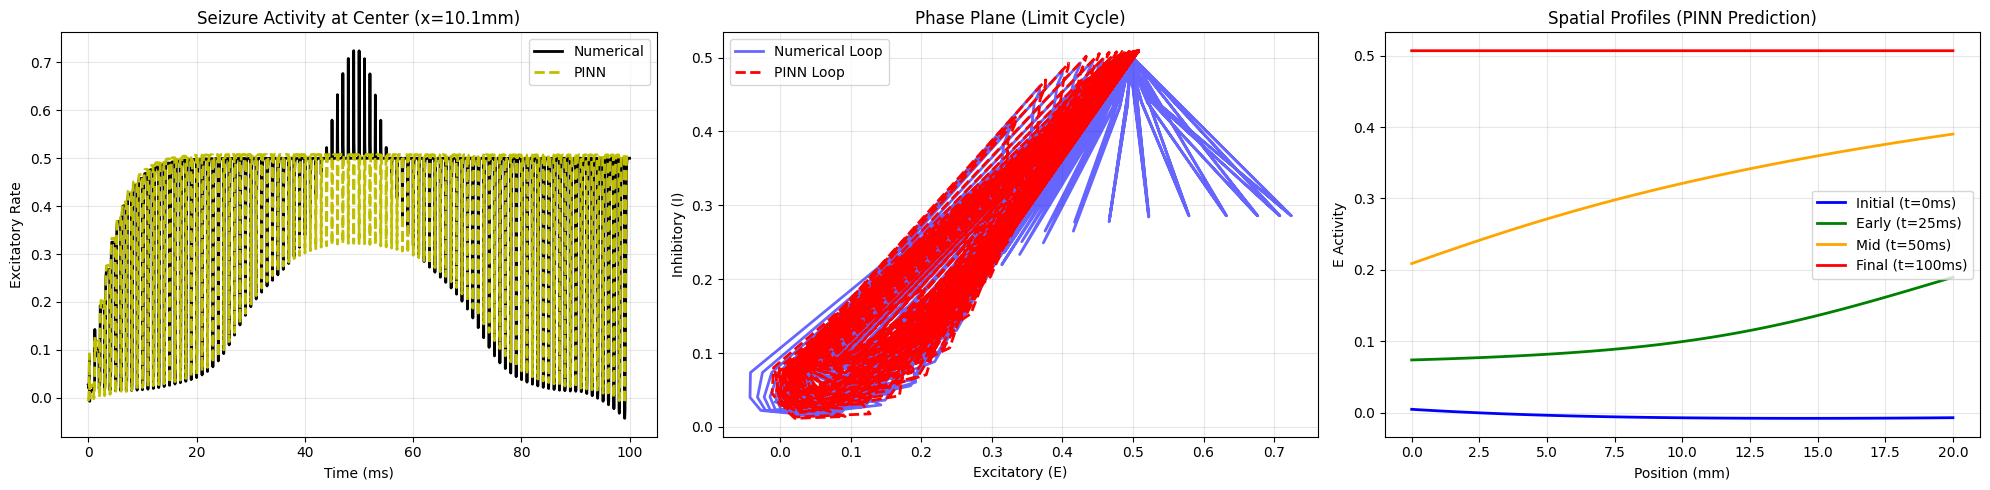

In [18]:
# ==========================================
# 1. Class Definitions
# ==========================================
class SeizureDataset(Dataset):
    def __init__(self, csv_file):
        data = pd.read_csv(csv_file)
        
        # Normalize inputs
        self.t_raw = data['t'].values.astype(np.float32)
        self.x_raw = data['x'].values.astype(np.float32)
        
        self.t_mean, self.t_std = self.t_raw.mean(), self.t_raw.std()
        self.x_mean, self.x_std = self.x_raw.mean(), self.x_raw.std()
        
        # Inputs: (t, x) normalized
        t_norm = (self.t_raw - self.t_mean) / self.t_std
        x_norm = (self.x_raw - self.x_mean) / self.x_std
        self.X = np.stack([t_norm, x_norm], axis=1)
        
        # Targets: (E, I)
        self.y = data[['E', 'I']].values.astype(np.float32)
        
        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2) 
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 2. The Loading & Analysis Function
# ==========================================
def load_and_analyze(model_path, data_path, title_prefix = "Model Analysis"):
    """
    Loads a saved PINN model and runs full dashboard analysis 
    (Heatmaps, Dynamics, Phase Plane, and Spatial Profiles).
    """
    
    # --- Check files ---
    if not os.path.exists(model_path):
        print(f"Error: Model file '{model_path}' not found.")
        return
    if not os.path.exists(data_path):
        print(f"Error: Data file '{data_path}' not found.")
        return

    print(f"Loading Data from: {data_path}")
    dataset = SeizureDataset(data_path)
    
    print(f"Loading Model from: {model_path}")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = PINN().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    print("Running Analysis...")
    
    # --- Prepare Data ---
    X_all = dataset.X.to(device)
    t_raw = dataset.t_raw
    x_raw = dataset.x_raw
    
    # Ground Truth
    y_true = dataset.y.numpy()
    E_true = y_true[:, 0]
    I_true = y_true[:, 1]
    
    # Predictions
    with torch.no_grad():
        preds = model(X_all).cpu().numpy()
        E_pred = preds[:, 0]
        I_pred = preds[:, 1]
    
    # Reshape for Grids (Time x Space -> Space x Time)
    unique_t = np.unique(t_raw)
    unique_x = np.unique(x_raw)
    n_t = len(unique_t)
    n_x = len(unique_x)
    
    try:
        # T (Transpose) makes rows=Space, Cols=Time
        E_true_grid = E_true.reshape(n_t, n_x).T
        E_pred_grid = E_pred.reshape(n_t, n_x).T
        I_true_grid = I_true.reshape(n_t, n_x).T
        I_pred_grid = I_pred.reshape(n_t, n_x).T
        
        Error_grid = np.abs(E_true_grid - E_pred_grid)
    except ValueError:
        print("Error reshaping data. Ensure the CSV contains a perfect grid of (t, x).")
        return

    # ========================================================
    # FIGURE 1: Heatmap Comparison
    # ========================================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Ground Truth
    im1 = axes[0].imshow(E_true_grid, aspect='auto', origin='lower',
                         extent=[t_raw.min(), t_raw.max(), x_raw.min(), x_raw.max()],
                         cmap='inferno')
    axes[0].set_title(f"Ground Truth\n({title_prefix})")
    axes[0].set_ylabel("Position (mm)")
    axes[0].set_xlabel("Time (ms)")
    plt.colorbar(im1, ax=axes[0])
    
    # Prediction
    im2 = axes[1].imshow(E_pred_grid, aspect='auto', origin='lower',
                         extent=[t_raw.min(), t_raw.max(), x_raw.min(), x_raw.max()],
                         cmap='inferno')
    axes[1].set_title(f"PINN Prediction\n({title_prefix})")
    axes[1].set_xlabel("Time (ms)")
    plt.colorbar(im2, ax=axes[1])
    
    # Error
    im3 = axes[2].imshow(Error_grid, aspect='auto', origin='lower',
                         extent=[t_raw.min(), t_raw.max(), x_raw.min(), x_raw.max()],
                         cmap='Greys')
    axes[2].set_title("Absolute Error Map")
    axes[2].set_xlabel("Time (ms)")
    plt.colorbar(im3, ax=axes[2], label="|True - Pred|")
    
    plt.tight_layout()
    plt.show()

    # ========================================================
    # FIGURE 2: Dynamics & Phase Plane (Center of Tissue)
    # ========================================================
    center_idx = n_x // 2
    
    # Extract time series at the center
    ts_true_E = E_true_grid[center_idx, :]
    ts_true_I = I_true_grid[center_idx, :]
    ts_pred_E = E_pred_grid[center_idx, :]
    ts_pred_I = I_pred_grid[center_idx, :]

    fig2, axes2 = plt.subplots(1, 3, figsize=(20, 5)) # Changed to 3 columns
    
    # 1. Time Series
    axes2[0].plot(unique_t, ts_true_E, 'k-', lw=2, label='Numerical')
    axes2[0].plot(unique_t, ts_pred_E, 'y--', lw=2, label='PINN')
    axes2[0].set_title(f"Seizure Activity at Center (x={unique_x[center_idx]:.1f}mm)")
    axes2[0].set_xlabel("Time (ms)")
    axes2[0].set_ylabel("Excitatory Rate")
    axes2[0].legend()
    axes2[0].grid(True, alpha=0.3)
    
    # 2. Phase Plane
    axes2[1].plot(ts_true_E, ts_true_I, 'b-', lw=2, alpha=0.6, label='Numerical Loop')
    axes2[1].plot(ts_pred_E, ts_pred_I, 'r--', lw=2, label='PINN Loop')
    axes2[1].set_title("Phase Plane (Limit Cycle)")
    axes2[1].set_xlabel("Excitatory (E)")
    axes2[1].set_ylabel("Inhibitory (I)")
    axes2[1].legend()
    axes2[1].grid(True, alpha=0.3)
    
    # 3. Spatial Profiles (ADDED THIS SECTION)
    # Select indices for Initial, Early, Mid, Final
    time_indices = [
        0,                  # Initial
        int(n_t * 0.25),    # Early
        int(n_t * 0.50),    # Mid
        n_t - 1             # Final
    ]
    colors = ['blue', 'green', 'orange', 'red']
    labels = ['Initial', 'Early', 'Mid', 'Final']
    
    for idx, color, label in zip(time_indices, colors, labels):
        t_val = unique_t[idx]
        profile = E_pred_grid[:, idx] # Spatial profile at this time
        axes2[2].plot(unique_x, profile, color=color, lw=2, label=f"{label} (t={t_val:.0f}ms)")
        
    axes2[2].set_title("Spatial Profiles (PINN Prediction)")
    axes2[2].set_xlabel("Position (mm)")
    axes2[2].set_ylabel("E Activity")
    axes2[2].legend()
    axes2[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. Usage Example
# ==========================================
if __name__ == "__main__":
    # Ensure you point to your specific files
    load_and_analyze(
        model_path='generalized_seizure_pinn.pth', 
        data_path='WC_1D_Seizure_Data_generalized.csv',
        title_prefix="Generalized Seizure"
    )